# Audio Classification: MotoSense


## 1. Library & Konfigurasi

In [1]:
import os, glob, shutil, random, warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import json
import numpy as np
import pandas as pd
import librosa
import soundfile as sf

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import Sequential, layers, regularizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import joblib
import os
import pickle
import io
from IPython.display import display, Audio, clear_output
import ipywidgets as widgets
from audiomentations import (
    Compose,
    AddGaussianNoise,
    LowPassFilter,
    BandPassFilter,
    ClippingDistortion,
    Gain,
    PitchShift,
    TimeStretch,
    Shift,
    PolarityInversion,
    OneOf
)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import distutils.util
import matplotlib.gridspec as gridspec
import tensorflow_hub as hub
import numpy as np
import os
import glob
import librosa
import tensorflow as tf
from tensorflow.keras import layers, Sequential, regularizers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

BASE_DIR      = "dataset"
TARGET_SR     = 16000
DURATION      = 2
TARGET_SAMPLES = TARGET_SR * DURATION
STRIDE_SAMPLES = int(TARGET_SR * 1.5)

CLASSES       = ["Clutch-Shoe", "Conecting-Rod", "Drive-Belt",
                 "Piston", "Tensioner", "Slider", "Roller", "Face-Drive"]

N_MELS       = 128
N_FFT        = 1024
HOP_LENGTH   = 375

AUG_TARGET   = 1000

BATCH_SIZE   = 8
EPOCHS       = 100
SEED         = 42

PATHS = {
    "raw"         : os.path.join(BASE_DIR, "part-rusak"),
    "rename"      : os.path.join(BASE_DIR, "rename"),
    "preprocessed": os.path.join(BASE_DIR, "preprocessed"),
    "augmented"   : os.path.join(BASE_DIR, "augmented"),
    "split"       : os.path.join(BASE_DIR, "split"),

    "features"    : os.path.join(BASE_DIR, "features"),
    "models"      : "models",
}

for p in PATHS.values():
    os.makedirs(p, exist_ok=True)


## 2. Rename File

In [2]:
for cls in CLASSES:
    src = os.path.join(PATHS['raw'], cls)
    dst = os.path.join(PATHS['rename'], cls)
    os.makedirs(dst, exist_ok=True)
    files = sorted(f for f in os.listdir(src) if f.endswith(('.wav','.mp3','.m4a')))
    for i, f in enumerate(files, 1):
        ext = os.path.splitext(f)[1]
        shutil.copy(os.path.join(src, f),
                    os.path.join(dst, f"{cls.lower()}-{i:03d}{ext}"))
    print(f"  {cls:<15}: {len(files)} file")

print(f"\nDisimpan ke: {PATHS['rename']}")

  Clutch-Shoe    : 15 file
  Conecting-Rod  : 10 file
  Drive-Belt     : 20 file
  Piston         : 6 file
  Tensioner      : 8 file
  Slider         : 13 file
  Roller         : 19 file
  Face-Drive     : 9 file

Disimpan ke: dataset/rename


## 3. EDA

In [3]:
durasi_dict = {}

print(f"{'KELAS':<15} | {'FILE':<5} | {'SAMPLE RATE':<12} | {'RATA-RATA':<10} | {'MIN':<6} | {'MAX':<6}")
print("-" * 80)

for cls in sorted(os.listdir(PATHS["raw"])):

    path = os.path.join(PATHS["raw"], cls)

    if not os.path.isdir(path):
        continue

    files = [
        f for f in os.listdir(path)
        if f.lower().endswith((".wav", ".mp3", ".m4a"))
    ]

    if len(files) == 0:
        continue

    durasi_list = [
        librosa.get_duration(path=os.path.join(path, f))
        for f in files
    ]

    _, sr = librosa.load(
        os.path.join(path, files[0]),
        sr=None
    )

    durasi_dict[cls] = durasi_list

    print(
        f"{cls:<15} | "
        f"{len(files):<5} | "
        f"{sr:<12} | "
        f"{np.mean(durasi_list):<8.2f}s | "
        f"{np.min(durasi_list):<4.2f}s | "
        f"{np.max(durasi_list):<4.2f}s"
    )

KELAS           | FILE  | SAMPLE RATE  | RATA-RATA  | MIN    | MAX   
--------------------------------------------------------------------------------
Clutch-Shoe     | 15    | 44100        | 2.51    s | 1.07s | 4.08s
Conecting-Rod   | 10    | 44100        | 2.37    s | 1.62s | 4.21s
Drive-Belt      | 20    | 44100        | 3.55    s | 1.60s | 6.75s
Face-Drive      | 9     | 44100        | 3.14    s | 1.20s | 4.82s
Piston          | 6     | 44100        | 1.74    s | 1.00s | 3.17s
Roller          | 19    | 44100        | 3.78    s | 1.53s | 9.15s
Slider          | 13    | 44100        | 3.91    s | 0.84s | 6.51s
Tensioner       | 8     | 44100        | 2.97    s | 1.59s | 7.41s


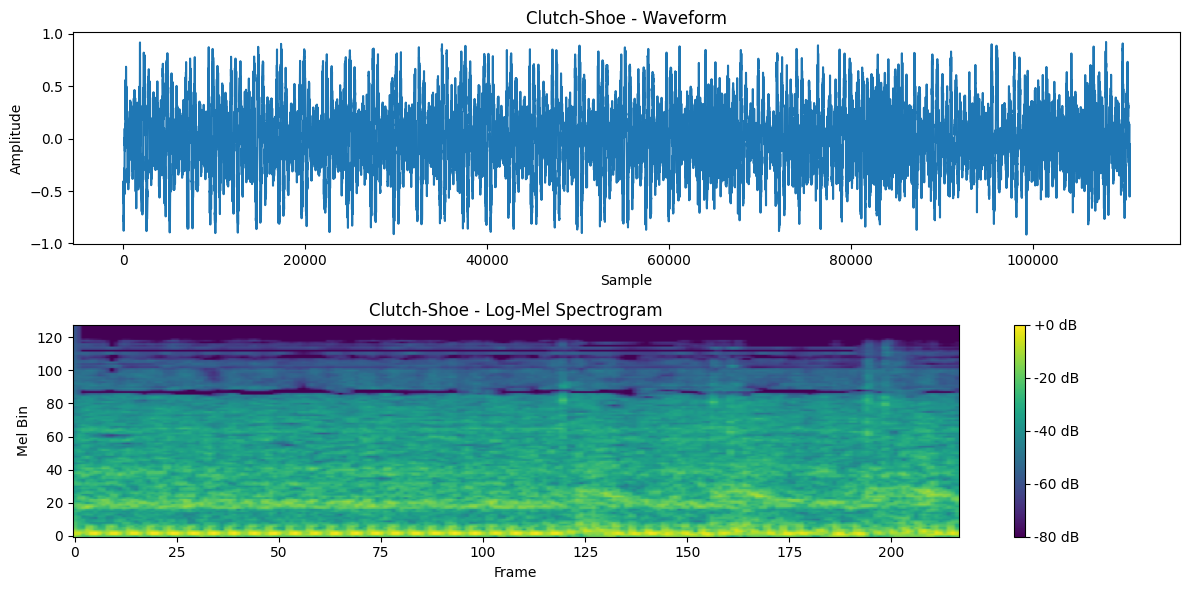

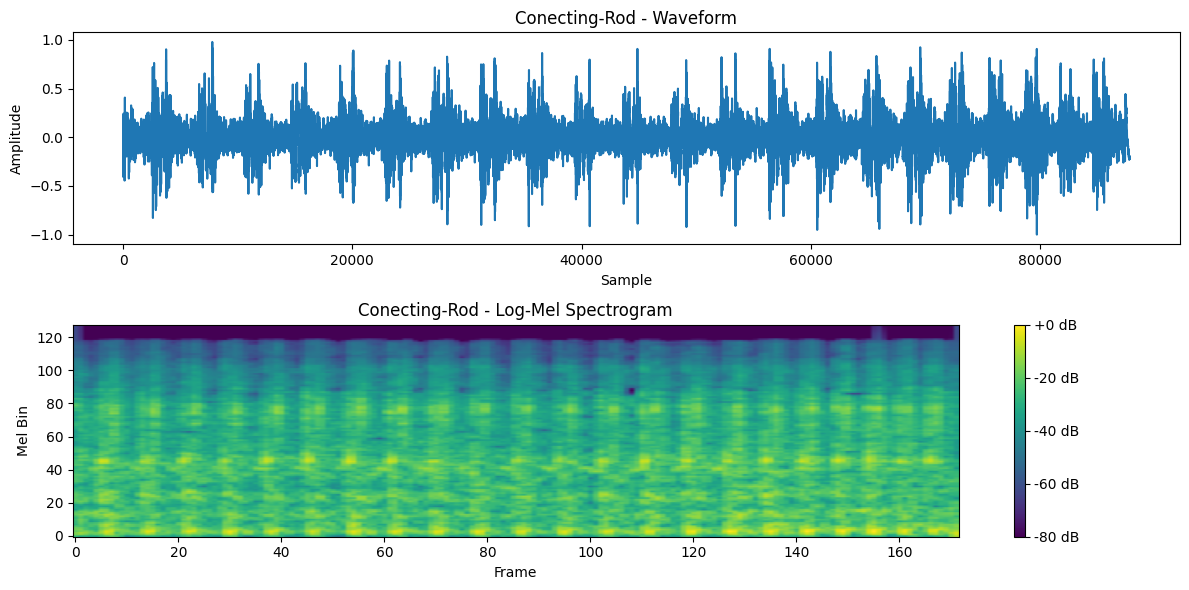

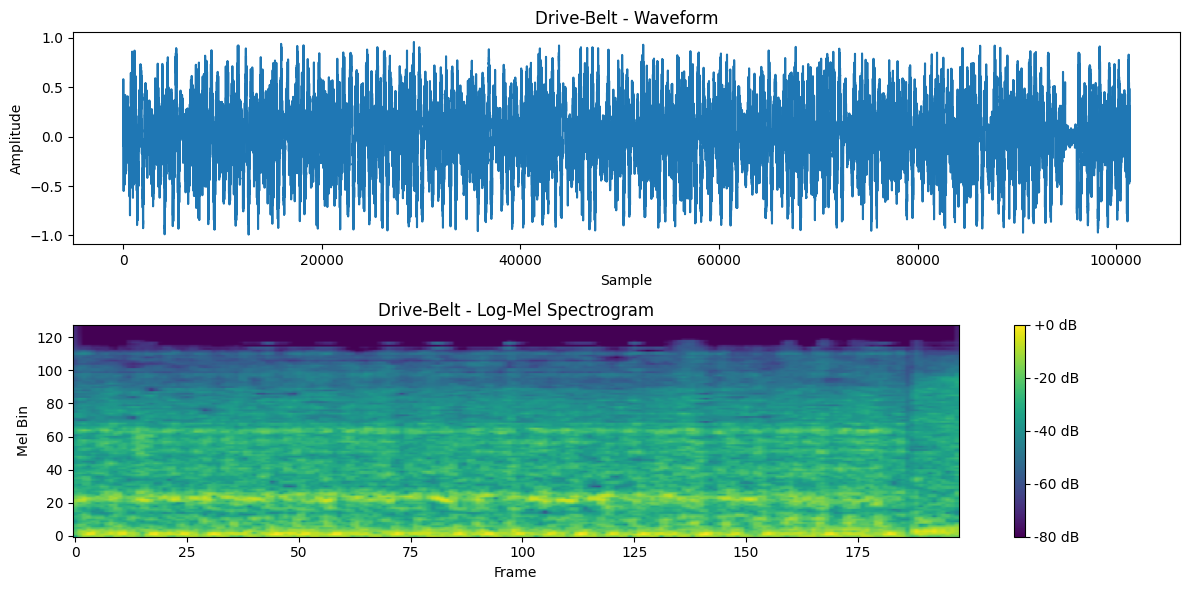

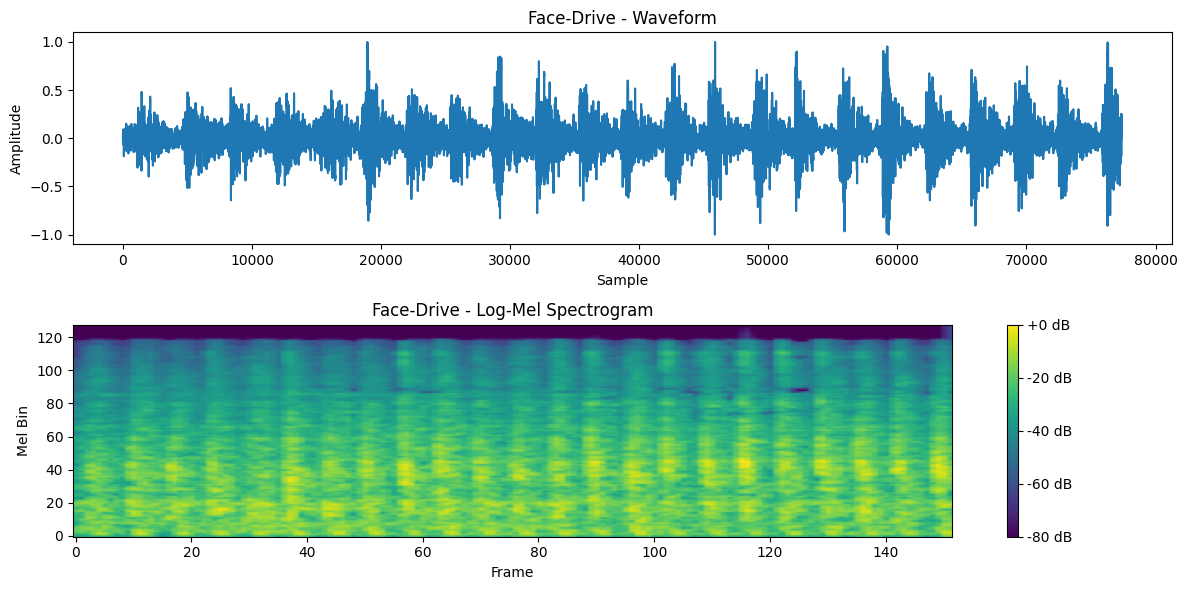

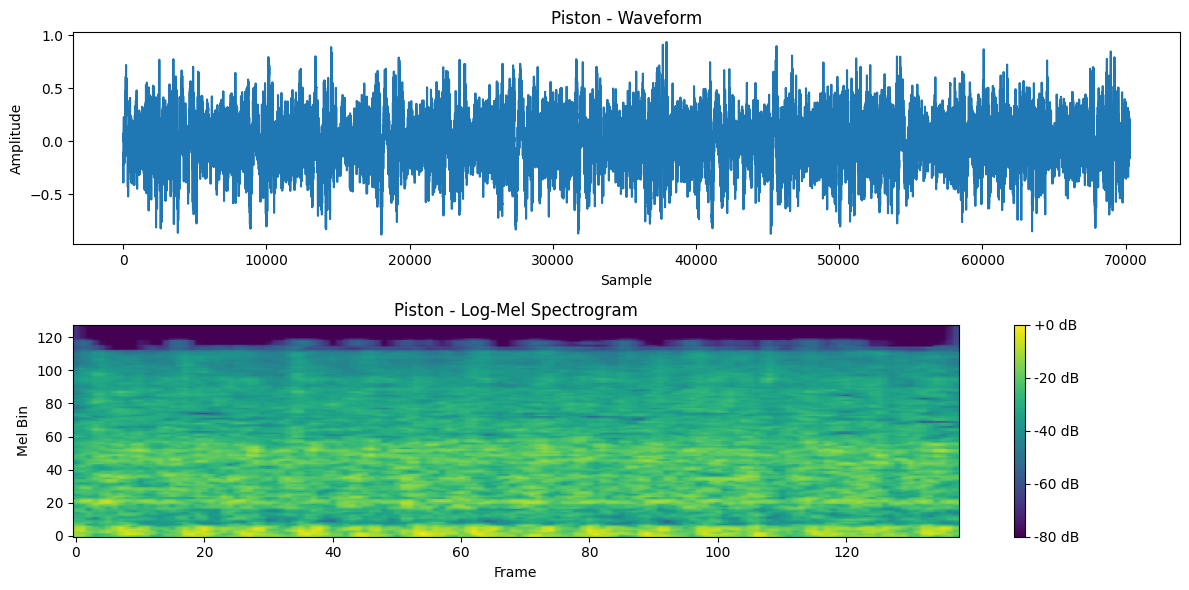

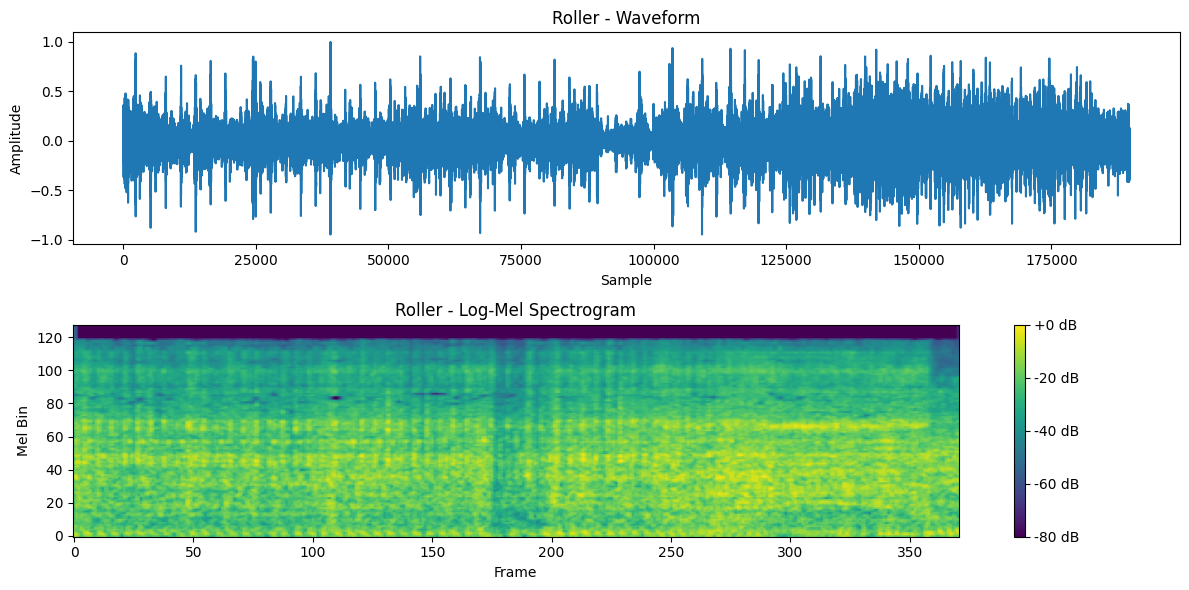

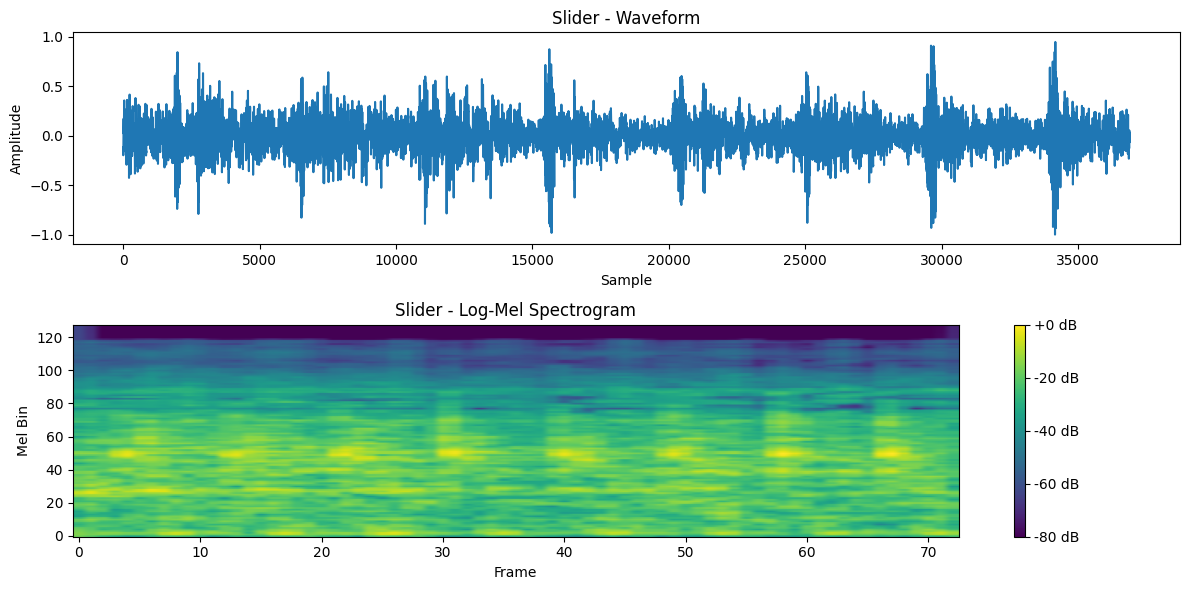

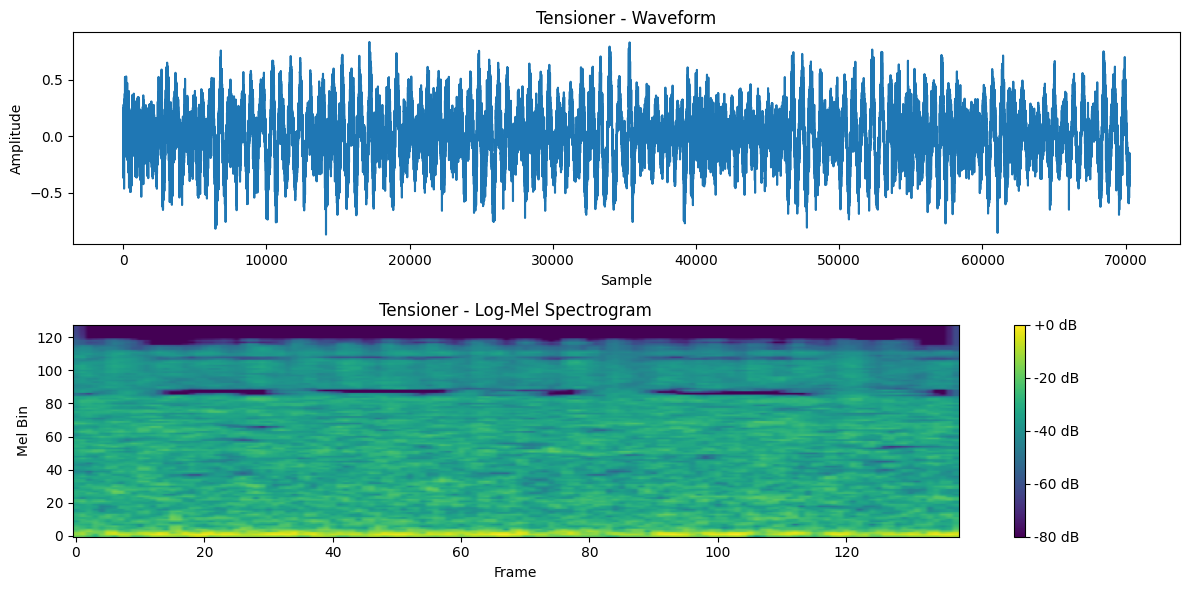

In [4]:
for cls in sorted(os.listdir(PATHS["raw"])):

    path = os.path.join(PATHS["raw"], cls)

    if not os.path.isdir(path):
        continue

    files = sorted([
        f for f in os.listdir(path)
        if f.lower().endswith((".wav", ".mp3", ".m4a"))
    ])

    if len(files) == 0:
        continue

    sample_file = os.path.join(path, files[0])

    y, sr = librosa.load(
        sample_file,
        sr=None
    )

    mel_spec = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=128
    )

    log_mel_spec = librosa.power_to_db(
        mel_spec,
        ref=np.max
    )

    plt.figure(figsize=(12, 6))

    plt.subplot(2, 1, 1)
    plt.plot(y)
    plt.title(f"{cls} - Waveform")
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")

    plt.subplot(2, 1, 2)
    plt.imshow(
        log_mel_spec,
        aspect="auto",
        origin="lower"
    )

    plt.title(f"{cls} - Log-Mel Spectrogram")
    plt.xlabel("Frame")
    plt.ylabel("Mel Bin")
    plt.colorbar(format="%+2.0f dB")

    plt.tight_layout()
    plt.show()

## 4. Preprocessing

In [5]:
def preprocess(path):
    y, _ = librosa.load(path, sr=TARGET_SR, mono=True)
    y, _ = librosa.effects.trim(y, top_db=30)
    peak  = np.max(np.abs(y))
    return y / peak if peak > 0 else y

def chunk_and_save(src_base, out_base):
    total = 0
    for cls in CLASSES:
        src_dir = os.path.join(src_base, cls)
        dst_dir = os.path.join(out_base, cls)
        os.makedirs(dst_dir, exist_ok=True)
        
        files = glob.glob(os.path.join(src_dir, '*.wav'))
        chunk_count = 0
        
        for f in files:
            audio = preprocess(f)
            base  = os.path.splitext(os.path.basename(f))[0]
            
            audio_len = len(audio)
            if audio_len < TARGET_SAMPLES:
                audio = np.tile(audio, int(np.ceil(TARGET_SAMPLES / audio_len)))
            
            chunks = [audio[i:i+TARGET_SAMPLES]
                     for i in range(0, len(audio)-TARGET_SAMPLES+1, STRIDE_SAMPLES)
                     if len(audio[i:i+TARGET_SAMPLES]) == TARGET_SAMPLES]
            
            for ci, chunk in enumerate(chunks):
                out_path = os.path.join(dst_dir, f"{base}_c{ci}.wav")
                sf.write(out_path, chunk, TARGET_SR, subtype='PCM_16')
                chunk_count += 1
        
        total += chunk_count
        print(f"  {cls:<15}: {chunk_count} chunks")
    
    return total

total_chunks = chunk_and_save(PATHS['rename'], PATHS['preprocessed'])
print(f"\n✓ Total chunks: {total_chunks} → {PATHS['preprocessed']}")


  Clutch-Shoe    : 19 chunks
  Conecting-Rod  : 13 chunks
  Drive-Belt     : 32 chunks
  Piston         : 6 chunks
  Tensioner      : 12 chunks
  Slider         : 29 chunks
  Roller         : 33 chunks
  Face-Drive     : 15 chunks

✓ Total chunks: 159 → dataset/preprocessed


## 5. Augmentasi

In [6]:

augment = Compose([

    OneOf([
        AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.010, p=1.0),
    ], p=0.80),

    OneOf([
        LowPassFilter(min_cutoff_freq=2500, max_cutoff_freq=8000, p=1.0),
        BandPassFilter(min_center_freq=300, max_center_freq=6000, 
                      min_bandwidth_fraction=0.4, max_bandwidth_fraction=0.9, p=1.0),
        ClippingDistortion(max_percentile_threshold=5, p=1.0),
    ], p=0.45),

    Gain(min_gain_db=-10, max_gain_db=8, p=0.70),

    Shift(min_shift=-0.15, max_shift=0.15, rollover=True, p=0.55),

    TimeStretch(min_rate=0.95, max_rate=1.05, p=0.25),
    PitchShift(min_semitones=-1, max_semitones=1, p=0.15),

    PolarityInversion(p=0.10),
])

def augment_dataset(src_base, out_base, target_count=AUG_TARGET):
    """
    Augmentasi data:
    - Copy semua file asli
    - Tambahkan augmentasi hingga mencapai target_count
    """
    for cls in CLASSES:
        src_dir = os.path.join(src_base, cls)
        dst_dir = os.path.join(out_base, cls)
        os.makedirs(dst_dir, exist_ok=True)
        
        existing = glob.glob(os.path.join(src_dir, '*.wav'))
        if len(existing) == 0:
            print(f"  {cls:<15}: tidak ada file, dilewati")
            continue
        
        for f in existing:
            shutil.copy(f, os.path.join(dst_dir, os.path.basename(f)))
        
        needed = max(0, target_count - len(existing))
        
        for i in range(needed):
            src_file = random.choice(existing)
            y, _ = librosa.load(src_file, sr=TARGET_SR, mono=True)
            
            y_aug = augment(samples=y.astype(np.float32), sample_rate=TARGET_SR)
            
            if len(y_aug) < TARGET_SAMPLES:
                y_aug = np.pad(y_aug, (0, TARGET_SAMPLES - len(y_aug)))
            else:
                y_aug = y_aug[:TARGET_SAMPLES]
            
            out_path = os.path.join(dst_dir, f"aug_{i:05d}.wav")
            sf.write(out_path, y_aug, TARGET_SR, subtype='PCM_16')
        
        final = len(glob.glob(os.path.join(dst_dir, '*.wav')))
        print(f"  {cls:<15}: {len(existing):>3} asli → {final} total (+{needed} aug)")

augment_dataset(PATHS['preprocessed'], PATHS['augmented'])
print(f"\n✓ Disimpan ke: {PATHS['augmented']}")


  Clutch-Shoe    :  19 asli → 1000 total (+981 aug)
  Conecting-Rod  :  13 asli → 1000 total (+987 aug)
  Drive-Belt     :  32 asli → 1000 total (+968 aug)
  Piston         :   6 asli → 1000 total (+994 aug)
  Tensioner      :  12 asli → 1000 total (+988 aug)
  Slider         :  29 asli → 1000 total (+971 aug)
  Roller         :  33 asli → 1000 total (+967 aug)
  Face-Drive     :  15 asli → 1000 total (+985 aug)

✓ Disimpan ke: dataset/augmented


## 6. Train/Val/Test Split

Split data awal untuk mencegah data leakage.

In [7]:
all_files, all_labels = [], []
for lbl, cls in enumerate(CLASSES):
    aug_dir = os.path.join(PATHS['augmented'], cls)
    for f in glob.glob(os.path.join(aug_dir, '*.wav')):
        all_files.append(f)
        all_labels.append(lbl)

print(f"Total file augmented: {len(all_files)}")

X_tmp, X_test, y_tmp, y_test = train_test_split(
    all_files, all_labels, 
    test_size=0.10,
    stratify=all_labels, 
    random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, 
    test_size=0.111,
    stratify=y_tmp, 
    random_state=SEED
)

splits = [
    ("train", X_train, y_train),
    ("val",   X_val,   y_val),
    ("test",  X_test,  y_test)
]

for split_name, files, labels in splits:
    count = 0
    for f, lbl in zip(files, labels):
        cls = CLASSES[lbl]
        dst_dir = os.path.join(PATHS['split'], split_name, cls)
        os.makedirs(dst_dir, exist_ok=True)
        shutil.copy(f, os.path.join(dst_dir, os.path.basename(f)))
        count += 1
    
    pct = (count / len(all_files)) * 100
    print(f"  {split_name:<6}: {count:>4} file ({pct:>5.1f}%) → {os.path.join(PATHS['split'], split_name)}")

print(f"\n✓ Total: {len(all_files)} file")
print(f"✓ Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")


Total file augmented: 8000
  train : 6400 file ( 80.0%) → dataset/split/train
  val   :  800 file ( 10.0%) → dataset/split/val
  test  :  800 file ( 10.0%) → dataset/split/test

✓ Total: 8000 file
✓ Train: 6400 | Val: 800 | Test: 800


## 7. Feature Extraction (Log-Mel Spectrogram)

Konversi audio ke matriks 2D (128x128).

### Visualisasi Spectrogram

Sample perbandingan waveform dan spectrogram.

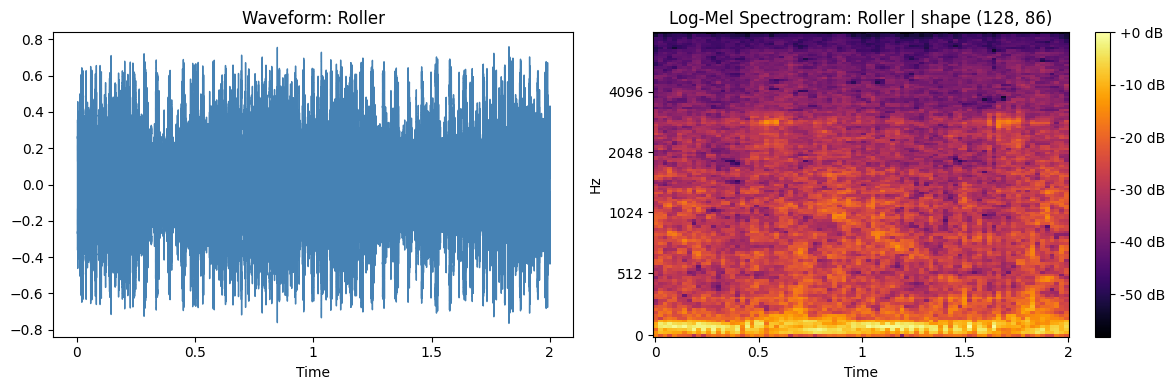

In [8]:
import random, matplotlib.pyplot as plt, librosa, librosa.display

sample_wavs = glob.glob(os.path.join(PATHS['split'],'train', '*', '*.wav'))
if sample_wavs:
    sample_path = random.choice(sample_wavs)
    cls_name    = os.path.basename(os.path.dirname(sample_path))
    y_s, sr_s   = librosa.load(sample_path, sr=TARGET_SR, mono=True)
    mel = librosa.feature.melspectrogram(y=y_s, sr=sr_s, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
    db  = librosa.power_to_db(mel, ref=np.max)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    librosa.display.waveshow(y_s, sr=sr_s, ax=ax[0], color='steelblue')
    ax[0].set_title(f'Waveform: {cls_name}')
    img = librosa.display.specshow(db, sr=sr_s, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel', ax=ax[1], cmap='inferno')
    plt.colorbar(img, ax=ax[1], format='%+2.0f dB')
    ax[1].set_title(f'Log-Mel Spectrogram: {cls_name} | shape {db.shape}')
    plt.tight_layout(); plt.show()

### Feature Extraction with YAMNet


In [9]:

print("Memuat model YAMNet dari TF Hub...")
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')
print("YAMNet berhasil dimuat!")

def extract_yamnet_embeddings(data_dir):
    X, y = [], []
    for lbl, cls in enumerate(CLASSES):
        files = glob.glob(os.path.join(data_dir, cls, '*.wav'))
        for f in files:
            wav, _ = librosa.load(f, sr=16000, mono=True)
            wav = wav / (np.max(np.abs(wav)) + 1e-8)
            _, embeddings, _ = yamnet_model(wav)

            emb = embeddings.numpy()

            emb_mean = np.mean(emb, axis=0)
            emb_std  = np.std(emb, axis=0)

            feature = np.concatenate([emb_mean, emb_std])
            X.append(emb_mean)
            y.append(lbl)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)
 
YAMNET_FEAT = {
    "train": (os.path.join(PATHS['features'], 'X_train_yamnet.npy'), os.path.join(PATHS['features'], 'y_train_yamnet.npy')),
    "val"  : (os.path.join(PATHS['features'], 'X_val_yamnet.npy'),   os.path.join(PATHS['features'], 'y_val_yamnet.npy')),
    "test" : (os.path.join(PATHS['features'], 'X_test_yamnet.npy'),  os.path.join(PATHS['features'], 'y_test_yamnet.npy')),
}
SRC = {
    "train": os.path.join(PATHS['split'], 'train'),
    "val": os.path.join(PATHS['split'], 'val'),
    "test": os.path.join(PATHS['split'], 'test')
}
print("\nEkstraksi fitur YAMNet...")
for subset, (xp, yp) in YAMNET_FEAT.items():
    if os.path.exists(xp):
        print(f"  {subset:<6}: cache ditemukan, skip")
    else:
        print(f"  {subset:<6}: mengekstrak...")
        X, y = extract_yamnet_embeddings(SRC[subset])
        np.save(xp, X); np.save(yp, y)
        print(f"  {subset:<6}: {X.shape} tersimpan")

X_train_yn = np.load(YAMNET_FEAT['train'][0]); y_train_yn = np.load(YAMNET_FEAT['train'][1])
X_val_yn   = np.load(YAMNET_FEAT['val'][0]);   y_val_yn   = np.load(YAMNET_FEAT['val'][1])
X_test_yn  = np.load(YAMNET_FEAT['test'][0]);  y_test_yn  = np.load(YAMNET_FEAT['test'][1])
print(f"\nX_train: {X_train_yn.shape} | X_val: {X_val_yn.shape} | X_test: {X_test_yn.shape}")

print("\nTrain :", X_train_yn.shape)
print("Val   :", X_val_yn.shape)
print("Test  :", X_test_yn.shape)

print("\nJumlah kelas:")
for i, cls in enumerate(CLASSES):
    print(cls, np.sum(y_train_yn == i))

Memuat model YAMNet dari TF Hub...
YAMNet berhasil dimuat!

Ekstraksi fitur YAMNet...
  train : cache ditemukan, skip
  val   : cache ditemukan, skip
  test  : cache ditemukan, skip

X_train: (6400, 1024) | X_val: (800, 1024) | X_test: (800, 1024)

Train : (6400, 1024)
Val   : (800, 1024)
Test  : (800, 1024)

Jumlah kelas:
Clutch-Shoe 800
Conecting-Rod 800
Drive-Belt 800
Piston 800
Tensioner 800
Slider 800
Roller 800
Face-Drive 800


In [10]:
print("Train :", X_train_yn.shape)
print("Val   :", X_val_yn.shape)
print("Test  :", X_test_yn.shape)

Train : (6400, 1024)
Val   : (800, 1024)
Test  : (800, 1024)


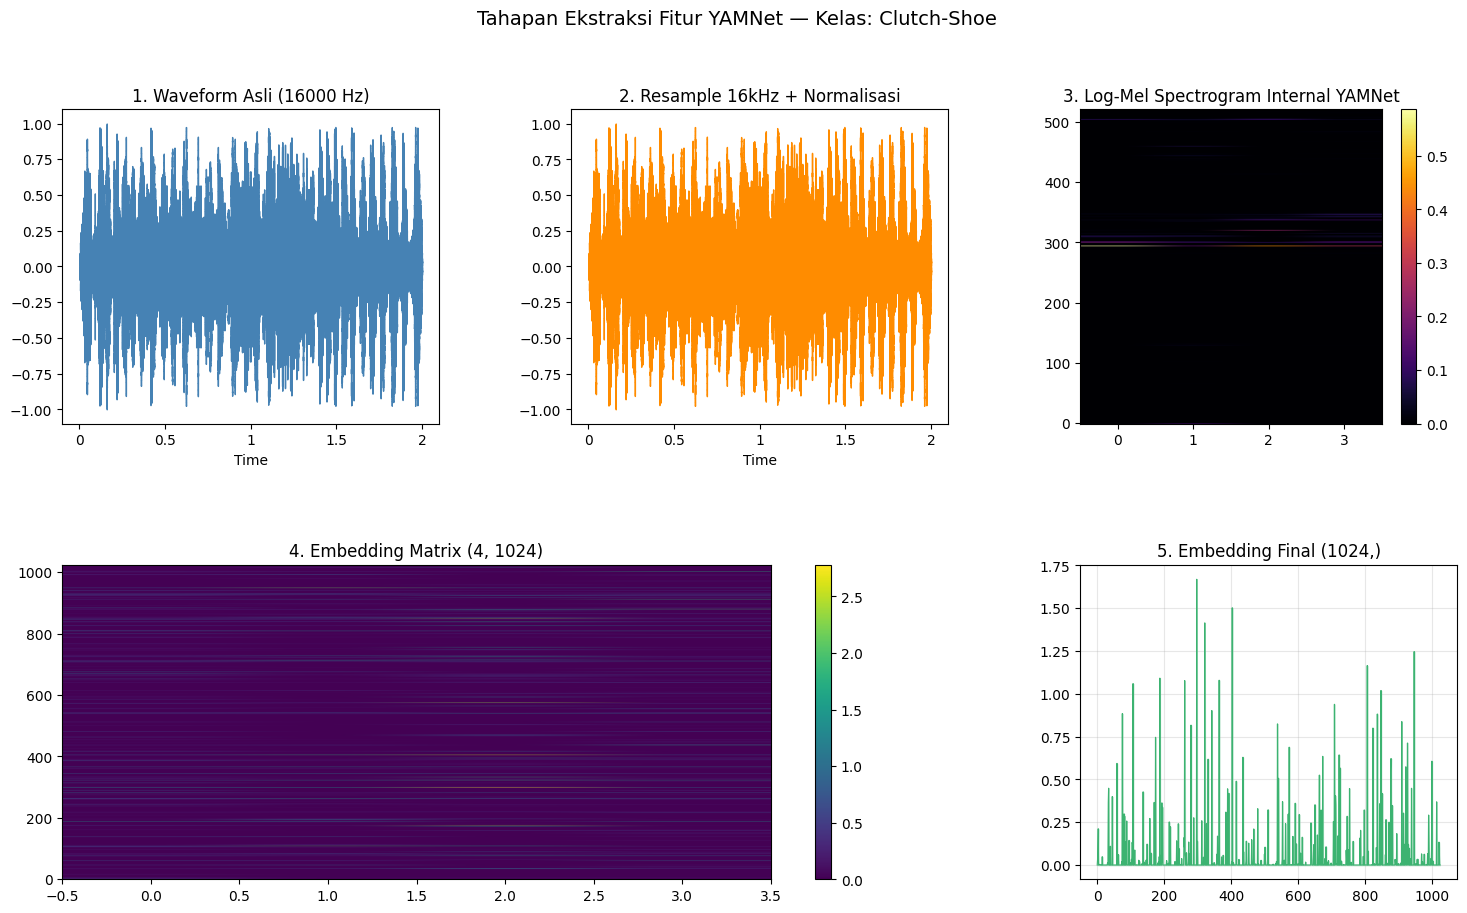

In [11]:

all_wavs = glob.glob(os.path.join(PATHS['split'],'train', '*', '*.wav'))
example_path = random.choice(all_wavs)
cls_name = os.path.basename(os.path.dirname(example_path))

wav_orig, sr_orig = librosa.load(example_path, sr=None, mono=True)
wav_16k, _ = librosa.load(example_path, sr=16000, mono=True)
wav_16k_norm = wav_16k / (np.max(np.abs(wav_16k)) + 1e-8)

log_mel_out, embeddings, _ = yamnet_model(wav_16k_norm)
emb_mean = np.mean(embeddings.numpy(), axis=0)

fig = plt.figure(figsize=(18, 10))
fig.suptitle(f'Tahapan Ekstraksi Fitur YAMNet — Kelas: {cls_name}', fontsize=14)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
librosa.display.waveshow(wav_orig, sr=sr_orig, ax=ax1, color='steelblue')
ax1.set_title(f'1. Waveform Asli ({sr_orig} Hz)')

ax2 = fig.add_subplot(gs[0, 1])
librosa.display.waveshow(wav_16k_norm, sr=16000, ax=ax2, color='darkorange')
ax2.set_title('2. Resample 16kHz + Normalisasi')

ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(log_mel_out.numpy().T, origin='lower', aspect='auto', cmap='inferno')
plt.colorbar(im3, ax=ax3); ax3.set_title('3. Log-Mel Spectrogram Internal YAMNet')

ax4 = fig.add_subplot(gs[1, 0:2])
im4 = ax4.imshow(embeddings.numpy().T, origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(im4, ax=ax4); ax4.set_title(f'4. Embedding Matrix {embeddings.numpy().shape}')

ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(emb_mean, color='mediumseagreen', linewidth=0.8)
ax5.fill_between(range(len(emb_mean)), emb_mean, alpha=0.3, color='mediumseagreen')
ax5.set_title(f'5. Embedding Final {emb_mean.shape}'); ax5.grid(alpha=0.3)
plt.show()

In [12]:
emb = embeddings.numpy()

print("Min :", emb.min())
print("Max :", emb.max())
print("Mean:", emb.mean())
print("Std :", emb.std())

Min : 0.0
Max : 2.7780626
Mean: 0.052587375
Std : 0.21769781


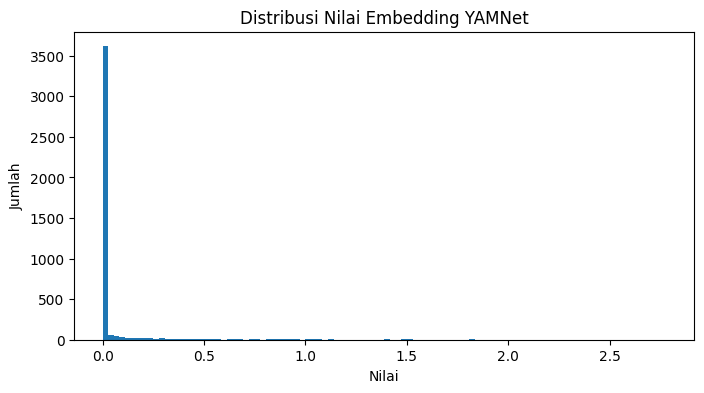

In [13]:
plt.figure(figsize=(8,4))
plt.hist(embeddings.numpy().flatten(), bins=100)
plt.title("Distribusi Nilai Embedding YAMNet")
plt.xlabel("Nilai")
plt.ylabel("Jumlah")
plt.show()

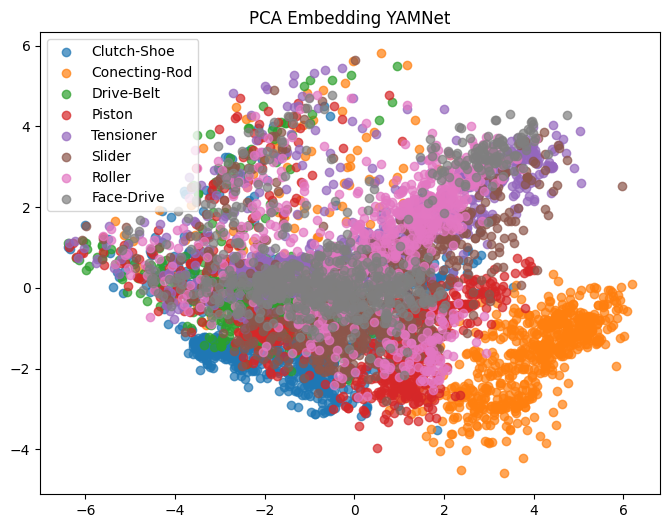

In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_yn)

plt.figure(figsize=(8,6))

for i, cls in enumerate(CLASSES):
    idx = y_train_yn == i
    plt.scatter(
        X_pca[idx,0],
        X_pca[idx,1],
        label=cls,
        alpha=0.7
    )

plt.legend()
plt.title("PCA Embedding YAMNet")
plt.show()

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


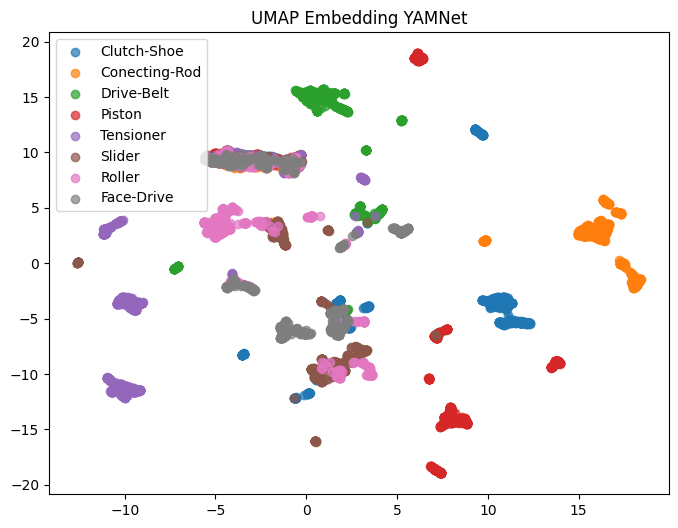

In [15]:
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)

X_umap = reducer.fit_transform(X_train_yn)

plt.figure(figsize=(8,6))

for i, cls in enumerate(CLASSES):
    idx = y_train_yn == i
    plt.scatter(
        X_umap[idx, 0],
        X_umap[idx, 1],
        label=cls,
        alpha=0.7
    )

plt.legend()
plt.title("UMAP Embedding YAMNet")
plt.show()

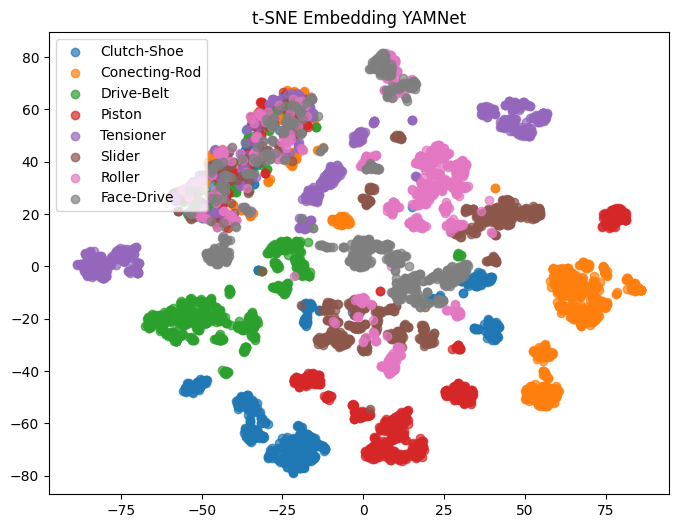

In [16]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=30, random_state=42)

X_tsne = tsne.fit_transform(X_train_yn)

plt.figure(figsize=(8,6))

for i, cls in enumerate(CLASSES):
    idx = y_train_yn == i
    plt.scatter(
        X_tsne[idx, 0],
        X_tsne[idx, 1],
        label=cls,
        alpha=0.7
    )

plt.legend()
plt.title("t-SNE Embedding YAMNet")
plt.show()

## 8. Training

### Standarisasi

In [17]:
scaler = StandardScaler()

X_train_sq = scaler.fit_transform(X_train_yn)

X_val_sq = scaler.transform(X_val_yn)

X_test_sq = scaler.transform(X_test_yn)

y_train_sq = y_train_yn
y_val_sq = y_val_yn
y_test_sq = y_test_yn


## 8.1 Dense Sequential model Arsitektur

In [18]:
def build_yamnet_classifier(n_classes):
    return Sequential([
        layers.Input(shape=(1024,)),
        layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.Dropout(0.5),
        layers.Dense(n_classes, activation='softmax')
    ], 
    name="yamnet_dense")

model = build_yamnet_classifier(len(CLASSES))
model.summary()

Model: "yamnet_dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 264,456 (1.01 MB)

 Trainable params: 264,456 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

### Traning & Callback 

Training YAMNet Dense Classifier...
Epoch 1/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5464 - loss: 1.5126 - val_accuracy: 0.7337 - val_loss: 1.0481 - learning_rate: 1.0000e-04
Epoch 2/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7311 - loss: 0.9695 - val_accuracy: 0.7812 - val_loss: 0.7802 - learning_rate: 1.0000e-04
Epoch 3/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7705 - loss: 0.7838 - val_accuracy: 0.8050 - val_loss: 0.6612 - learning_rate: 1.0000e-04
Epoch 4/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7931 - loss: 0.6794 - val_accuracy: 0.8300 - val_loss: 0.5832 - learning_rate: 1.0000e-04
Epoch 5/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8180 - loss: 0.5949 - val_accuracy: 0.8400 - val_loss: 0.5298 - learning_rate: 1.0000e-04
Epoch 6/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8284 - loss: 0.5537 - val_accuracy: 0.8450 - val_loss: 0.4992 - learning_rate: 1.0000e-04
Epoch 7/100
800/800 ━━

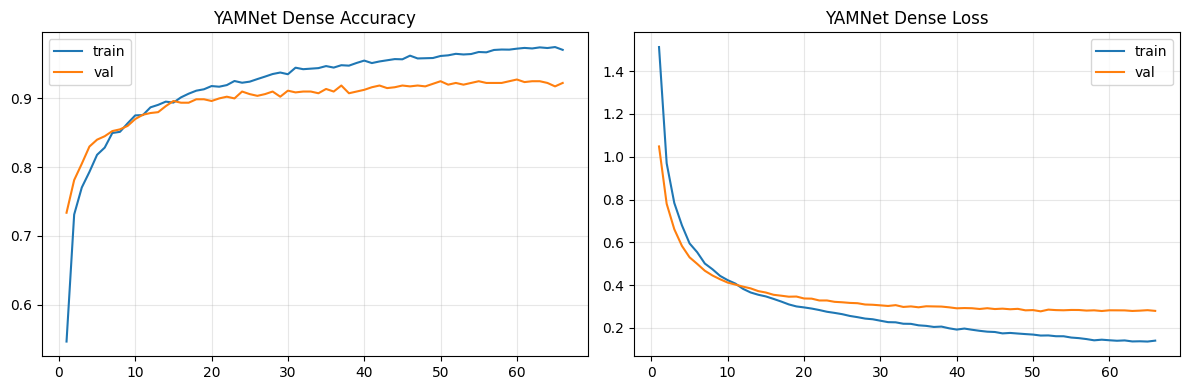

In [19]:

model_yn = build_yamnet_classifier(len(CLASSES))
model_yn.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                 loss='sparse_categorical_crossentropy', metrics=['accuracy'])

callbacks_yn = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

print("Training YAMNet Dense Classifier...")
history_yn = model_yn.fit(
    X_train_yn, y_train_yn,
    validation_data=(X_val_yn, y_val_yn),
    epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=callbacks_yn, verbose=1
)

loss, acc = model_yn.evaluate(X_test_yn, y_test_yn, verbose=0)
print(f"\nAkurasi YAMNet Dense pada Test Set: {acc*100:.2f}%")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(history_yn.history['loss']) + 1)
ax[0].plot(ep, history_yn.history['accuracy'],     label='train')
ax[0].plot(ep, history_yn.history['val_accuracy'], label='val')
ax[0].set_title('YAMNet Dense Accuracy'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(ep, history_yn.history['loss'],     label='train')
ax[1].plot(ep, history_yn.history['val_loss'], label='val')
ax[1].set_title('YAMNet Dense Loss'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Clasification Report

In [20]:
from sklearn.metrics import classification_report

y_pred = np.argmax(
    model_yn.predict(X_test_yn),
    axis=1
)

print(
    classification_report(
        y_test_yn,
        y_pred,
        target_names=CLASSES
    )
)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 718us/step
               precision    recall  f1-score   support

  Clutch-Shoe       0.95      0.90      0.92       100
Conecting-Rod       0.98      0.96      0.97       100
   Drive-Belt       0.98      0.95      0.96       100
       Piston       0.93      0.97      0.95       100
    Tensioner       0.93      0.93      0.93       100
       Slider       0.91      0.95      0.93       100
       Roller       0.91      0.90      0.90       100
   Face-Drive       0.85      0.88      0.87       100

     accuracy                           0.93       800
    macro avg       0.93      0.93      0.93       800
 weighted avg       0.93      0.93      0.93       800



### confusion matriks

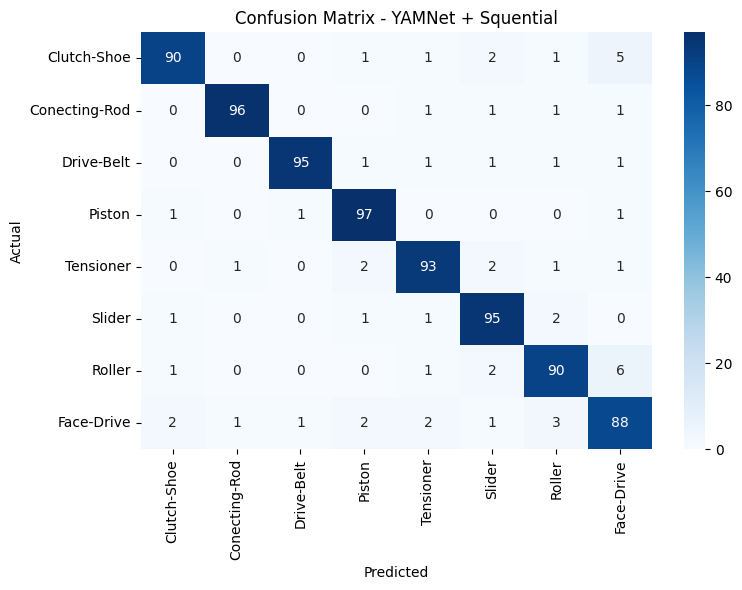

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_sq, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap= 'Blues',
    xticklabels=CLASSES,
    yticklabels=CLASSES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - YAMNet + Squential")

plt.tight_layout()
plt.show()

### Save Model

In [22]:
import os

SEQ_DIRS = {
    'keras': os.path.join(PATHS['models'], 'sequential', 'keras'),
    'tflite': os.path.join(PATHS['models'], 'sequential', 'tflite'),

    'scaler': os.path.join(PATHS['models'], 'sequential', 'scaler'),
    'metadata': os.path.join(PATHS['models'], 'sequential', 'metadata'),
}

for path in SEQ_DIRS.values():
    os.makedirs(path, exist_ok=True)

for key, path in SEQ_DIRS.items():
    print(f"{key:<10}: {path}")

keras     : models/sequential/keras
tflite    : models/sequential/tflite
scaler    : models/sequential/scaler
metadata  : models/sequential/metadata


In [23]:
h5_path = os.path.join(
    SEQ_DIRS['keras'],
    'yamnet_sequential.h5'
)

model_yn.save(h5_path)

print(f"Saved H5 : {h5_path}")

keras_path = os.path.join(
    SEQ_DIRS['keras'],
    'yamnet_sequential.keras'
)

model_yn.save(keras_path)

print(f"Saved Keras : {keras_path}")

tflite_path = os.path.join(
    SEQ_DIRS['tflite'],
    'yamnet_sequential.tflite'
)

converter = tf.lite.TFLiteConverter.from_keras_model(
    model_yn
)

tflite_model = converter.convert()

with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print(f"Saved TFLite : {tflite_path}")

import joblib

joblib.dump(
    scaler,
    os.path.join(
        SEQ_DIRS['scaler'],
        'yamnet_scaler.joblib'
    )
)

print("Scaler saved")

metadata = {
    "classes": CLASSES,
    "num_classes": len(CLASSES),
    "feature_extractor": "YAMNet",
    "embedding_size": int(X_train_yn.shape[1])

}

with open(
    os.path.join(
        SEQ_DIRS['metadata'],
        'metadata.json'
    ),
    'w'
) as f:
    json.dump(metadata, f, indent=4)


Saved H5 : models/sequential/keras/yamnet_sequential.h5
Saved Keras : models/sequential/keras/yamnet_sequential.keras
INFO:tensorflow:Assets written to: /var/folders/56/db9c3yn534757rq3twrpchw40000gn/T/tmptqgitx57/assets


INFO:tensorflow:Assets written to: /var/folders/56/db9c3yn534757rq3twrpchw40000gn/T/tmptqgitx57/assets


Saved artifact at '/var/folders/56/db9c3yn534757rq3twrpchw40000gn/T/tmptqgitx57'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1024), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float32, name=None)
Captures:
  14403306320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14403305552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14509437392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14403310160: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved TFLite : models/sequential/tflite/yamnet_sequential.tflite
Scaler saved


## 8.2 SVM

In [24]:
from sklearn.preprocessing import StandardScaler

print("\nNormalisasi fitur YAMNet untuk SVM...")

scaler_svm = StandardScaler()

X_train_svm = scaler_svm.fit_transform(X_train_yn)
X_val_svm   = scaler_svm.transform(X_val_yn)
X_test_svm  = scaler_svm.transform(X_test_yn)

y_train_svm = y_train_yn
y_val_svm   = y_val_yn
y_test_svm  = y_test_yn

print("Normalisasi SVM selesai.")


Normalisasi fitur YAMNet untuk SVM...
Normalisasi SVM selesai.


In [25]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,
    random_state=42
)

print("Training SVM...")

svm_model.fit(X_train_svm, y_train_svm)

val_pred = svm_model.predict(X_val_svm)
val_acc = accuracy_score(y_val_svm, val_pred)

print(f"Validation Accuracy : {val_acc*100:.2f}%")

Training SVM...
Validation Accuracy : 91.50%


In [26]:
test_pred = svm_model.predict(X_test_svm)

test_acc = accuracy_score(y_test_svm, test_pred)

print(f"\nTest Accuracy : {test_acc*100:.2f}%")


Test Accuracy : 90.62%


In [27]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_svm,
        test_pred,
        target_names=CLASSES
    )
)

               precision    recall  f1-score   support

  Clutch-Shoe       0.73      0.92      0.81       100
Conecting-Rod       0.99      0.86      0.92       100
   Drive-Belt       0.93      0.90      0.91       100
       Piston       0.99      0.97      0.98       100
    Tensioner       0.91      0.91      0.91       100
       Slider       0.93      0.89      0.91       100
       Roller       0.93      0.91      0.92       100
   Face-Drive       0.91      0.89      0.90       100

     accuracy                           0.91       800
    macro avg       0.91      0.91      0.91       800
 weighted avg       0.91      0.91      0.91       800



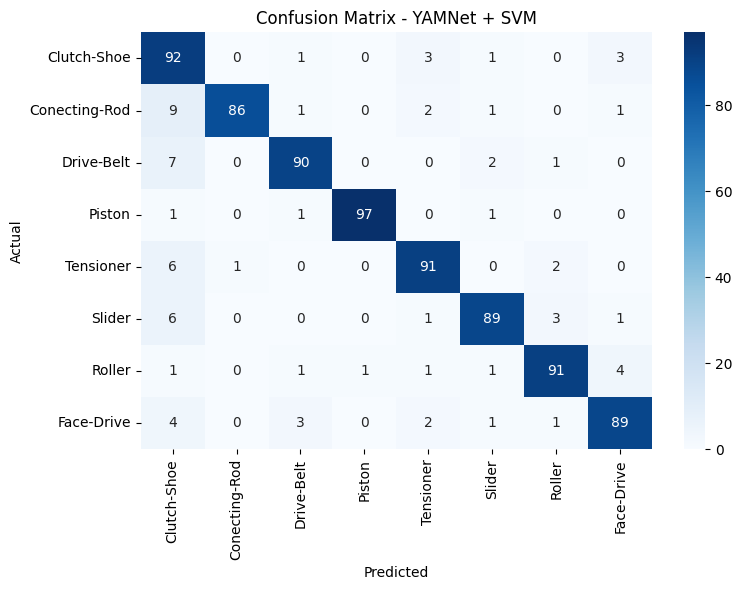

In [28]:

cm = confusion_matrix(y_test_svm, test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap= 'Blues',
    xticklabels=CLASSES,
    yticklabels=CLASSES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - YAMNet + SVM")

plt.tight_layout()
plt.show()

### Save Model

In [29]:
import os

SVM_DIRS = {
    'model': os.path.join(PATHS['models'], 'svm', 'model'),
    'scaler': os.path.join(PATHS['models'], 'svm', 'scaler'),
    'metadata': os.path.join(PATHS['models'], 'svm', 'metadata'),
}

for path in SVM_DIRS.values():
    os.makedirs(path, exist_ok=True)

for key, path in SVM_DIRS.items():
    print(f"{key:<10}: {path}")

model     : models/svm/model
scaler    : models/svm/scaler
metadata  : models/svm/metadata


In [30]:
import joblib

svm_path = os.path.join(
    SVM_DIRS['model'],
    'yamnet_svm.joblib'
)

joblib.dump(
    svm_model,
    svm_path
)

print(f"Saved SVM : {svm_path}")

joblib.dump(
    scaler_svm,
    os.path.join(
        SVM_DIRS['scaler'],
        'yamnet_svm_scaler.joblib'
    )
)

print("SVM scaler saved")

with open(
    os.path.join(
        SVM_DIRS['metadata'],
        'metadata.json'
    ),
    'w'
) as f:
    json.dump(metadata, f, indent=4)

Saved SVM : models/svm/model/yamnet_svm.joblib
SVM scaler saved


## 8.3 Random Forest

In [31]:
print("\nPersiapan fitur untuk Random Forest...")

X_train_rf = X_train_yn.copy()
X_val_rf   = X_val_yn.copy()
X_test_rf  = X_test_yn.copy()

y_train_rf = y_train_yn
y_val_rf   = y_val_yn
y_test_rf  = y_test_yn



Persiapan fitur untuk Random Forest...


In [32]:

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

rf_model.fit(X_train_rf, y_train_rf)

val_pred_rf = rf_model.predict(X_val_rf)

val_acc_rf = accuracy_score(y_val_rf, val_pred_rf)

print(f"Validation Accuracy RF : {val_acc_rf*100:.2f}%")

test_pred_rf = rf_model.predict(X_test_rf)

test_acc_rf = accuracy_score(y_test_rf, test_pred_rf)

print(f"Test Accuracy RF : {test_acc_rf*100:.2f}%")

Training Random Forest...
Validation Accuracy RF : 90.38%
Test Accuracy RF : 92.75%


In [33]:

print(
    classification_report(
        y_test_rf,
        test_pred_rf,
        target_names=CLASSES
    )
)

               precision    recall  f1-score   support

  Clutch-Shoe       0.97      0.88      0.92       100
Conecting-Rod       0.99      0.97      0.98       100
   Drive-Belt       0.93      0.96      0.95       100
       Piston       0.93      0.95      0.94       100
    Tensioner       0.92      0.93      0.93       100
       Slider       0.91      0.93      0.92       100
       Roller       0.89      0.91      0.90       100
   Face-Drive       0.88      0.89      0.89       100

     accuracy                           0.93       800
    macro avg       0.93      0.93      0.93       800
 weighted avg       0.93      0.93      0.93       800



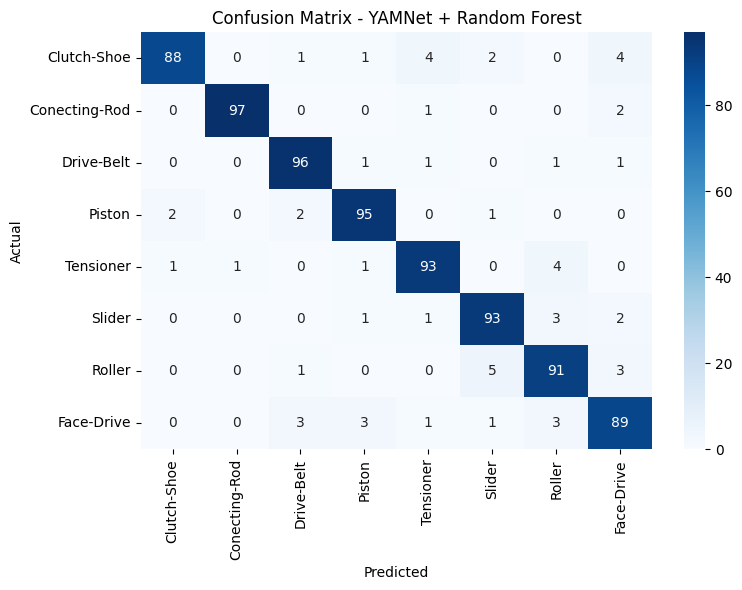

In [34]:

cm_rf = confusion_matrix(y_test_rf, test_pred_rf)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap= 'Blues',
    xticklabels=CLASSES,
    yticklabels=CLASSES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - YAMNet + Random Forest")

plt.tight_layout()
plt.show()

### Save Model

In [35]:
import os

RF_DIRS = {
    'model': os.path.join(PATHS['models'], 'random_forest', 'model'),
    'scaler': os.path.join(PATHS['models'], 'random_forest', 'scaler'),
    'metadata': os.path.join(PATHS['models'], 'random_forest', 'metadata'),
}

for path in RF_DIRS.values():
    os.makedirs(path, exist_ok=True)

for key, path in RF_DIRS.items():
    print(f"{key:<10}: {path}")

model     : models/random_forest/model
scaler    : models/random_forest/scaler
metadata  : models/random_forest/metadata


In [36]:
import joblib

rf_path = os.path.join(
    RF_DIRS['model'],
    'yamnet_rf.joblib'
)

joblib.dump(
    rf_model,
    rf_path
)

print(f"Saved RF : {rf_path}")

with open(
    os.path.join(
        RF_DIRS['metadata'],
        'metadata.json'
    ),
    'w'
) as f:
    json.dump(metadata, f, indent=4)


Saved RF : models/random_forest/model/yamnet_rf.joblib


## Perbandingan Model

In [37]:

def evaluate_model(name, y_true, y_pred):

    acc = accuracy_score(y_true, y_pred)

    prec = precision_score(
        y_true,
        y_pred,
        average='weighted',
        zero_division=0
    )

    rec = recall_score(
        y_true,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average='weighted'
    )

    print(f"\n{name}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")

evaluate_model(
    "Squential",
    y_test_sq,
    y_pred
)

evaluate_model(
    "SVM",
    y_test_yn,
    test_pred
)

evaluate_model(
    "Random Forest",
    y_test_yn,
    test_pred_rf
)



Squential
Accuracy  : 0.9300
Precision : 0.9307
Recall    : 0.9300
F1 Score  : 0.9301

SVM
Accuracy  : 0.9062
Precision : 0.9138
Recall    : 0.9062
F1 Score  : 0.9080

Random Forest
Accuracy  : 0.9275
Precision : 0.9283
Recall    : 0.9275
F1 Score  : 0.9275


## 10. Inference Pipeline

Pengujian model pada data raw `.wav`.

In [38]:
SEQ_MODEL_PATH = os.path.join(PATHS['models'], 'sequential', 'tflite', 'yamnet_sequential.tflite')

try:
    
    interpreter = tf.lite.Interpreter(model_path=SEQ_MODEL_PATH)
    interpreter.allocate_tensors()
    
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    
    print(f"   Model loaded from: {SEQ_MODEL_PATH}")
    print(f"   Model input shape: {input_details[0]['shape']}")
    print(f"   Model output shape: {output_details[0]['shape']}")
except FileNotFoundError:
    print(f"   Model tidak ditemukan di: {SEQ_MODEL_PATH}")
    print(f"   Pastikan model sudah disimpan terlebih dahulu")
except Exception as e:
    print(f"   Error loading model: {e}")

print("\n Loading Scaler...")
SCALER_PATH = os.path.join(PATHS['models'], 'sequential', 'scaler', 'yamnet_scaler.joblib')

try:

    scaler = joblib.load(SCALER_PATH)
    print(f"   Scaler loaded from: {SCALER_PATH}")
except FileNotFoundError:
    print(f"   Scaler tidak ditemukan di: {SCALER_PATH}")
    print(f"   Pastikan scaler sudah disimpan terlebih dahulu")
except Exception as e:
    print(f"   Error loading scaler: {e}")

   Model loaded from: models/sequential/tflite/yamnet_sequential.tflite
   Model input shape: [   1 1024]
   Model output shape: [1 8]

 Loading Scaler...
   Scaler loaded from: models/sequential/scaler/yamnet_scaler.joblib


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [39]:

import os
import io
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import librosa
import joblib
import ipywidgets as widgets
from IPython.display import Audio, display, clear_output

print("Memuat komponen model...")

try:
    yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')
    print(" YAMNet loaded successfully")
except Exception as e:
    print(f" Error loading YAMNet: {e}")

SEQ_MODEL_PATH = os.path.join(PATHS['models'], 'sequential', 'tflite', 'yamnet_sequential.tflite')
try:
    interpreter = tf.lite.Interpreter(model_path=SEQ_MODEL_PATH)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    print(f" TFLite Model loaded from: {SEQ_MODEL_PATH}")
except Exception as e:
    print(f" Error loading TFLite model: {e}")

SCALER_PATH = os.path.join(PATHS['models'], 'sequential', 'scaler', 'yamnet_scaler.joblib')
try:
    scaler = joblib.load(SCALER_PATH)
    print(f" Scaler loaded from: {SCALER_PATH}")
except Exception as e:
    print(f" Error loading scaler: {e}")

def preprocess_audio_for_inference(audio_bytes):
    """Preprocessing sinkron dengan pipeline training."""

    wav, sr = librosa.load(io.BytesIO(audio_bytes), sr=16000, mono=True)

    wav, _ = librosa.effects.trim(wav, top_db=30)

    wav_norm = wav / (np.max(np.abs(wav)) + 1e-8)

    scores, embeddings, spectrogram = yamnet_model(wav_norm)
    emb = embeddings.numpy()

    emb_mean = np.mean(emb, axis=0)
    
    return emb_mean, wav_norm

def display_prediction_result(filename, model_name, predicted_class, confidence):
    """Fungsi pembantu untuk mencetak hasil dengan rapi."""
    print(f"\n🎯 HASIL PREDIKSI [{model_name}]:")
    print(f"   File       : {filename}")
    print(f"   Kelas      : {predicted_class}")
    print(f"   Confidence : {confidence:.2%}")

def inference_sequential(audio_bytes, filename):
    """Menjalankan inference menggunakan model TFLite."""
    try:

        embedding, wav_norm = preprocess_audio_for_inference(audio_bytes)
        
        embedding_scaled = scaler.transform(embedding.reshape(1, -1))
        
        input_data = np.array(embedding_scaled, dtype=np.float32)
        expected_shape = input_details[0]['shape']
        
        if list(input_data.shape) != list(expected_shape):
            input_data = input_data.reshape(expected_shape)
            
        interpreter.set_tensor(input_details[0]['index'], input_data)
        interpreter.invoke()
        prediction = interpreter.get_tensor(output_details[0]['index'])
        
        predicted_class_idx = np.argmax(prediction, axis=1)[0]
        predicted_class = CLASSES[predicted_class_idx]
        confidence = float(prediction[0][predicted_class_idx])
        
        print("\n🎵 Audio yang diproses:")
        display(Audio(wav_norm, rate=16000))
        
        display_prediction_result(filename, "TFLite", predicted_class, confidence)
        
        print("\n Probabilitas per kelas:")
        for i, cls in enumerate(CLASSES):
            prob = prediction[0][i]
            prob_clamped = max(0.0, min(1.0, prob)) 
            bar = ' ' * int(prob_clamped * 50)
            marker = "->" if i == predicted_class_idx else "  "
            print(f"{marker} {cls:<15}: {prob:.4f} |{bar}")
            
        return predicted_class, confidence, prediction[0]

    except Exception as e:
        print(f"\nTerjadi kesalahan saat memproses '{filename}': {e}")
        return None, None, None

upload_widget = widgets.FileUpload(
    accept='.wav,.mp3,.m4a',
    multiple=False,
    description='1. Upload Audio',
    button_style='info'
)

button_predict = widgets.Button(
    description='2. Klasifikasi',
    button_style='success',
    icon='check'
)

output_area = widgets.Output()

def on_predict_clicked(b):
    with output_area:
        clear_output()
        
        if not upload_widget.value:
            print("Silakan upload file audio terlebih dahulu!")
            return
            
        try:

            if isinstance(upload_widget.value, tuple):

                uploaded_file = upload_widget.value[0]
                filename = uploaded_file['name']
                audio_bytes = uploaded_file['content']
            elif isinstance(upload_widget.value, dict):

                filename = list(upload_widget.value.keys())[0]
                audio_bytes = upload_widget.value[filename]['content']
            else:
                print("Format file upload tidak dikenali oleh widget.")
                return

            print(f"Memproses: {filename}...")
            inference_sequential(audio_bytes, filename)
            
        except Exception as e:
             print(f"Terjadi kesalahan pembacaan file widget: {e}")

button_predict.on_click(on_predict_clicked)


print("Pilih file audio, lalu klik 'Klasifikasi'.")
display(widgets.HBox([upload_widget, button_predict]))
display(output_area)

Memuat komponen model...
 YAMNet loaded successfully
 TFLite Model loaded from: models/sequential/tflite/yamnet_sequential.tflite
 Scaler loaded from: models/sequential/scaler/yamnet_scaler.joblib
Pilih file audio, lalu klik 'Klasifikasi'.


Output()

In [40]:
pip freeze >  requirement.txt

Note: you may need to restart the kernel to use updated packages.
